# Diffrax Scratch
Scratch code testing ODEs using diffrax

In [1]:
# %% Import JAX and enable 64-bit precision
import jax
jax.config.update("jax_enable_x64", True)

In [2]:
# %% Import other libraries
import equinox as eqx
import interpax
import diffrax
import optimistix as optx

import numpy as np
import jax.numpy as jnp
import jax.tree_util as jtu
from dataclasses import dataclass
from functools import partial, reduce
import numpy as np
from collections import namedtuple
from typing import NamedTuple
import matplotlib.pyplot as plt
import os

from netCDF4 import Dataset

from jaxtyping import ArrayLike, Real, Array
from tqdm.notebook import tqdm

In [3]:
# %% Load my own libraries
%load_ext autoreload
%autoreload 2
from c1lgkt.jax.analysis.configuration import load_yaml_config, realize_initial_conditions
import c1lgkt.jax.particles.particle_motion as particle_motion
import c1lgkt.jax.particles.particle_tools as particle_tools

In [6]:
# %% Load YAML config
args, ic_gen = load_yaml_config('./scratch/data/nt_analysis.yaml')
y0, mask, ic = realize_initial_conditions(ic_gen, args)

Loaded theta and clebsch mapping from file


In [5]:
# %% Some testing on fields

class TestField(eqx.Module):
    interp: interpax.Interpolator1D
    fields: str | list[str] = eqx.field(static=True)

    def __call__(self, r: Real, z: Real) -> dict[str, Real]:
        f = self.interp(r) * jnp.cos(z)

        if isinstance(self.fields, str):
            return {self.fields: f}
        else:
            return {field: f[..., i] for i, field in enumerate(self.fields)}
        

def sum_dicts(dicts: list[dict[str, Array]]) -> dict[str, Array]:
    keys = set().union(*dicts)
    return {
        k: reduce(jnp.add, (d[k] for d in dicts if k in d))
        for k in keys
    }

class TestModule(eqx.Module):
    fields: list[TestField]

    @jax.jit
    def __call__(self, r: Real, z: Real) -> dict[str, Real]:
        field_values = [field(r, z) for field in self.fields]
        return sum_dicts(field_values)

x = np.linspace(0, 10, 100)
f = np.sin(x)

x2 = np.linspace(0, 10, 50)
f2 = jnp.array([np.sin(x2), np.cos(x2)]).T

interp = interpax.Interpolator1D(x, f)
test_field = TestField(interp, fields='phi')
interp2 = interpax.Interpolator1D(x2, f2)
test_field2 = TestField(interp2, fields=['phi', 'apar'])

test_module = TestModule(fields=[test_field, test_field2])


In [14]:
y_test = jnp.linspace(0, 10, 32)
g_test = jnp.zeros((32, 32, 2, 2))
interp2d = interpax.Interpolator2D(y_test, y_test, g_test, method='cubic2')

interp2d(1.5, 1.5)


Array([[0., 0.],
       [0., 0.]], dtype=float64)

In [11]:
fgrad = jax.vmap(jax.jacrev(test_module.__call__, argnums=(0, 1)))(jnp.array([1.0, 2.0, 3.0]), jnp.array([0.5, 1.0, 1.5]))

In [13]:
fgrad['phi']

(Array([ 0.94672098, -0.44934503, -0.14020918], dtype=float64),
 Array([-0.80687275, -1.53022786, -0.28139659], dtype=float64))

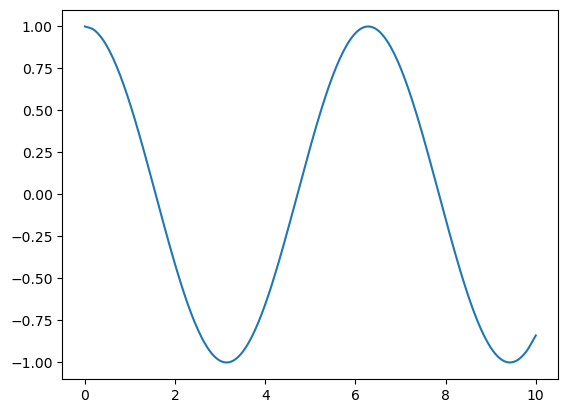

In [43]:
plt.figure()
plt.plot(x_test, f_test['apar'], label='phi')